In [1]:
import pandas as pd
import geohash2

from traffic_monitoring_ml.data import create_data_map
from traffic_monitoring_ml.config import DATA_PROCESSED_DIR,COLLISION_VALUE_MAP_PATH, VEHICLE_VALUE_MAP_PATH, CASUALTY_VALUE_MAP_PATH, COLLISION_CSV_URL, CASUALTY_CSV_URL, VEHICLE_CSV_URL, X_TRAIN_PATH, X_TEST_PATH, Y_TRAIN_PATH, Y_TEST_PATH, GROUPS_TRAIN_PATH
from traffic_monitoring_ml.utils import save_pickle, get_day_period_from_time, plot_target_dist
from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit

In [2]:
pd.set_option('display.max_columns', 100)

In [3]:
casualty = pd.read_csv(CASUALTY_CSV_URL)
vehicle = pd.read_csv(VEHICLE_CSV_URL,  dtype={'generic_make_model': str})
collision = pd.read_csv(COLLISION_CSV_URL)

In [4]:
casualty_value_map = create_data_map('casualty', casualty.columns)
vehicle_value_map = create_data_map('vehicle', vehicle.columns)
collision_value_map = create_data_map('collision', collision.columns)

In [5]:
value_maps = {
    Path(COLLISION_VALUE_MAP_PATH): collision_value_map,
    Path(VEHICLE_VALUE_MAP_PATH): vehicle_value_map,
    Path(CASUALTY_VALUE_MAP_PATH): casualty_value_map,
}

for path, data in value_maps.items():
    save_pickle(path, data)

In [6]:
casualty.replace(casualty_value_map)

,collision_index,collision_year,collision_ref_no,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,casualty_severity,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_imd_decile,lsoa_of_casualty,enhanced_casualty_severity,casualty_injury_based,casualty_adjusted_severity_serious,casualty_adjusted_severity_slight,casualty_distance_banding
0,2020010280094,2020,010280094,1,1,Pedestrian,Female,24,21 - 25,Slight,"In centre of carriageway - not on refuge, isla...",Unknown or other,Not car passenger,Not a bus or coach passenger,No / Not applicable,Pedestrian,More deprived 20-30%,E01003536,Data missing or out of range,Based on severity reporting,0.00000,1.00000,Data missing or out of range
1,202031D109620,2020,31D109620,1,1,Pedestrian,Female,95,Over 75,Serious,"In carriageway, crossing elsewhere",Crossing from driver's nearside,Not car passenger,Not a bus or coach passenger,No / Not applicable,Pedestrian,Less deprived 40-50%,E01028156,Data missing or out of range,Based on severity reporting,1.00000,0.00000,Data missing or out of range
2,2020401003715,2020,401003715,1,1,Pedestrian,Male,39,36 - 45,Slight,"In carriageway, crossing elsewhere",Crossing from driver's nearside,Not car passenger,Not a bus or coach passenger,No / Not applicable,Pedestrian,More deprived 10-20%,E01017492,Slight,Based on Injury code reporting,0.00000,1.00000,Data missing or out of range
3,2021201086330,2021,201086330,1,1,Pedestrian,Male,63,56 - 65,Slight,On footway or verge,Unknown or other,Not car passenger,Not a bus or coach passenger,Not Known,Pedestrian,More deprived 20-30%,E01009140,Slight,Based on Injury code reporting,0.00000,1.00000,Data missing or out of range
4,2021371050963,2021,371050963,1,1,Pedestrian,Male,51,46 - 55,Slight,"In carriageway, not crossing",Unknown or other,Not car passenger,Not a bus or coach passenger,No / Not applicable,Pedestrian,Less deprived 10-20%,E01030190,Slight,Based on Injury code reporting,0.00000,1.00000,Data missing or out of range
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
640517,2022430195626,2022,430195626,1,1,Pedestrian,Female,35,26 - 35,Slight,On footway or verge,Unknown or other,Not car passenger,Not a bus or coach passenger,No / Not applicable,Pedestrian,Least deprived 10%,E01028616,Data missing or out of range,Based on severity reporting,0.02644,0.97356,Data missing or out of range
640518,2022451135038,2022,451135038,1,1,Pedestrian,Female,12,11 - 15,Serious,"In centre of carriageway - not on refuge, isla...",Crossing from driver's nearside,Not car passenger,Not a bus or coach passenger,No / Not applicable,Pedestrian,Less deprived 20-30%,E01030580,Less Serious,Based on Injury code reporting,1.00000,0.00000,Data missing or out of range
640519,2023421294508,2023,421294508,1,1,Pedestrian,Male,50,46 - 55,Slight,Crossing elsewhere within 50m. of pedestrian c...,Crossing from driver's nearside,Not car passenger,Not a bus or coach passenger,No / Not applicable,Pedestrian,More deprived 10-20%,E01021592,Slight,Based on Injury code reporting,0.00000,1.00000,Data missing or out of range
640520,2024311507759,2024,311507759,2,1,Driver or rider,Male,25,21 - 25,Serious,Not a Pedestrian,Not a Pedestrian,Not car passenger,Not a bus or coach passenger,No / Not applicable,Data missing or out of range,Data missing or out of range,-1,Less Serious,Based on Injury code reporting,1.00000,0.00000,Data missing or out of range


In [7]:
vehicle.head().replace(vehicle_value_map)

,collision_index,collision_year,collision_ref_no,vehicle_reference,vehicle_type,towing_and_articulation,vehicle_manoeuvre_historic,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,vehicle_location_restricted_lane_historic,vehicle_location_restricted_lane,junction_location,skidding_and_overturning,hit_object_in_carriageway,vehicle_leaving_carriageway,hit_object_off_carriageway,first_point_of_impact,vehicle_left_hand_drive,journey_purpose_of_driver_historic,journey_purpose_of_driver,sex_of_driver,age_of_driver,age_band_of_driver,engine_capacity_cc,propulsion_code,age_of_vehicle,generic_make_model,driver_imd_decile,lsoa_of_driver,escooter_flag,driver_distance_banding
0,2020210979534,2020,210979534,2,Motorcycle over 500cc,No tow/articulation,Waiting to go - held up,Waiting to go ahead,South East,South West,On main c'way - not in restricted lane,On main carriageway (not in restricted lane),Not at or within 20 metres of junction,No skidding,No hit,Did not leave carriageway,No hit,Back,No,Other,Not known or not requested,Male,57,56 - 65,798,Petrol,4,BMW F 800,More deprived 20-30%,E01010422,Vehicle was not an e-scooter,NaN
1,2020030959800,2020,030959800,1,Motorcycle over 500cc,No tow/articulation,Going ahead right-hand bend,Going ahead,North East,South West,On main c'way - not in restricted lane,On main carriageway (not in restricted lane),Not at or within 20 metres of junction,No skidding,No hit,Nearside,No hit,Front,No,Not known,Not known or not requested,Male,59,56 - 65,798,Petrol,3,BMW F 800,Less deprived 40-50%,E01025351,Vehicle was not an e-scooter,NaN
2,2020360978858,2020,360978858,2,Motorcycle over 500cc,No tow/articulation,Going ahead other,Going ahead,North West,South East,On main c'way - not in restricted lane,On main carriageway (not in restricted lane),Not at or within 20 metres of junction,Overturned,No hit,Did not leave carriageway,No hit,Front,No,Commuting to/from work,Commuting to or from work,Male,64,56 - 65,798,Petrol,11,BMW F 800,More deprived 30-40%,E01026874,Vehicle was not an e-scooter,NaN
3,2020430340711,2020,430340711,1,Motorcycle over 500cc,No tow/articulation,Going ahead other,Going ahead,East,West,On main c'way - not in restricted lane,On main carriageway (not in restricted lane),Not at or within 20 metres of junction,No skidding,No hit,Offside,Tree,Front,No,Not known,Not known or not requested,Male,48,46 - 55,798,Petrol,8,BMW F 800,Less deprived 20-30%,E01017758,Vehicle was not an e-scooter,NaN
4,2020010260297,2020,010260297,1,Motorcycle over 500cc,No tow/articulation,unknown (self reported),unknown (self reported),unknown (self reported),unknown (self reported),unknown (self reported),unknown (self reported),Not at or within 20 metres of junction,unknown (self reported),unknown (self reported),unknown (self reported),unknown (self reported),unknown (self reported),No,Commuting to/from work,Commuting to or from work,Male,36,36 - 45,798,Petrol,9,BMW F 800,Less deprived 20-30%,E01016121,Vehicle was not an e-scooter,NaN


In [8]:
collision.head().replace(collision_value_map)

,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,number_of_casualties,date,day_of_week,time,local_authority_district,local_authority_ons_district,local_authority_highway,local_authority_highway_current,first_road_class,first_road_number,road_type,speed_limit,junction_detail_historic,junction_detail,junction_control,second_road_class,second_road_number,pedestrian_crossing_human_control_historic,pedestrian_crossing_physical_facilities_historic,pedestrian_crossing,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,2021170H10421,2021,170H10421,447098.0,532997.0,-1.270905,54.689833,Cleveland,Slight,2,2,22/05/2021,Saturday,22:44,Code deprecated,Hartlepool,Hartlepool,E06000001,Unclassified,first_road_class is C or Unclassified. These r...,Single carriageway,60,Not at junction or within 20 metres,Not at junction or within 20 metres,Data missing or out of range,Not at junction or within 20 metres,-1,None within 50 metres,No physical crossing facilities within 50 metres,No physical crossing facility within 50m,Darkness - no lighting,Fine no high winds,Dry,No,No hazards,No hazards,Rural,Yes,Non-trunk,E01011959,Data missing or out of range,Based on severity reporting,0.293588,0.706412
1,2021170H11231,2021,170H11231,450486.0,533118.0,-1.218333,54.690592,Cleveland,Slight,2,1,20/10/2021,Wednesday,15:50,Code deprecated,Hartlepool,Hartlepool,E06000001,B,1277,Single carriageway,30,Crossroads,Crossroads,Auto traffic signal,C,first_road_class is C or Unclassified. These r...,None within 50 metres,No physical crossing facilities within 50 metres,No physical crossing facility within 50m,Daylight,Fine no high winds,Dry,No,No hazards,No hazards,Urban,No,Non-trunk,E01011973,Data missing or out of range,Based on severity reporting,0.017448,0.982552
2,2020170M11750,2020,170M11750,449694.0,519733.0,-1.232884,54.570397,Cleveland,Slight,2,1,01/12/2020,Tuesday,18:00,Middlesbrough,Middlesbrough,Middlesbrough,E06000002,Unclassified,first_road_class is C or Unclassified. These r...,Single carriageway,20,Crossroads,Crossroads,Give way or uncontrolled,Unclassified,first_road_class is C or Unclassified. These r...,None within 50 metres,No physical crossing facilities within 50 metres,No physical crossing facility within 50m,Darkness - lights lit,Fine no high winds,Dry,No,No hazards,No hazards,Urban,Yes,Non-trunk,E01012092,Data missing or out of range,Based on severity reporting,0.128730,0.871270
3,2021170M31761,2021,170M31761,449744.0,514217.0,-1.233040,54.520825,Cleveland,Slight,1,1,09/12/2021,Thursday,16:55,Code deprecated,Middlesbrough,Middlesbrough,E06000002,C,first_road_class is C or Unclassified. These r...,Single carriageway,40,Not at junction or within 20 metres,Not at junction or within 20 metres,Data missing or out of range,Not at junction or within 20 metres,-1,None within 50 metres,No physical crossing facilities within 50 metres,No physical crossing facility within 50m,Darkness - lights lit,Fine no high winds,Wet or damp,No,No hazards,No hazards,Rural,Yes,Non-trunk,E01032553,Data missing or out of range,Based on severity reporting,0.182698,0.817302
4,2021170S10441,2021,170S10441,445971.0,520834.0,-1.290292,54.580641,Cleveland,Slight,3,1,12/04/2021,Monday,09:02,Code deprecated,Stockton-on-Tees,Stockton-on-Tees,E06000004,A,19,Dual carriageway,70,Not at junction or within 20 metres,Not at junction or within 20 metres,Data missing or out of range,Not at junction or within 20 metres,-1,None within 50 metres,No physical crossing facilities within 50 metres,No physical crossing facility within 50m,Daylight,Fine no high winds,Dry,Roadwo

In [9]:
collision.columns

Index(['collision_index', 'collision_year', 'collision_ref_no',
       'location_easting_osgr', 'location_northing_osgr', 'longitude',
       'latitude', 'police_force', 'collision_severity', 'number_of_vehicles',
       'number_of_casualties', 'date', 'day_of_week', 'time',
       'local_authority_district', 'local_authority_ons_district',
       'local_authority_highway', 'local_authority_highway_current',
       'first_road_class', 'first_road_number', 'road_type', 'speed_limit',
       'junction_detail_historic', 'junction_detail', 'junction_control',
       'second_road_class', 'second_road_number',
       'pedestrian_crossing_human_control_historic',
       'pedestrian_crossing_physical_facilities_historic',
       'pedestrian_crossing', 'light_conditions', 'weather_conditions',
       'road_surface_conditions', 'special_conditions_at_site',
       'carriageway_hazards_historic', 'carriageway_hazards',
       'urban_or_rural_area', 'did_police_officer_attend_scene_of_accident',
 

In [10]:
casualty = casualty.drop(columns=['collision_ref_no'])
vehicle = vehicle.drop(columns=['collision_ref_no','collision_year'])
collision = collision.drop(columns=['collision_ref_no','collision_year'])

cas_veh = pd.merge(casualty, vehicle, on=['collision_index','vehicle_reference'], how='inner')
accidents = pd.merge(cas_veh, collision, on=['collision_index'], how='inner')

In [11]:
accidents.head()

,collision_index,collision_year,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,casualty_severity,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_imd_decile,lsoa_of_casualty,enhanced_casualty_severity,casualty_injury_based,casualty_adjusted_severity_serious,casualty_adjusted_severity_slight,casualty_distance_banding,vehicle_type,towing_and_articulation,vehicle_manoeuvre_historic,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,vehicle_location_restricted_lane_historic,vehicle_location_restricted_lane,junction_location,skidding_and_overturning,hit_object_in_carriageway,vehicle_leaving_carriageway,hit_object_off_carriageway,first_point_of_impact,vehicle_left_hand_drive,journey_purpose_of_driver_historic,journey_purpose_of_driver,sex_of_driver,age_of_driver,age_band_of_driver,engine_capacity_cc,propulsion_code,age_of_vehicle,generic_make_model,driver_imd_decile,lsoa_of_driver,escooter_flag,driver_distance_banding,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,number_of_casualties,date,day_of_week,time,local_authority_district,local_authority_ons_district,local_authority_highway,local_authority_highway_current,first_road_class,first_road_number,road_type,speed_limit,junction_detail_historic,junction_detail,junction_control,second_road_class,second_road_number,pedestrian_crossing_human_control_historic,pedestrian_crossing_physical_facilities_historic,pedestrian_crossing,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,2020010280094,2020,1,1,3,2,24,5,3,8,9,0,0,0,0,3,E01003536,-1,0,0.0,1.0,-1,9,0,99,99,9,9,99,99,0,9,99,9,99,9,9,6,6,3,-1,-1,-1,-1,-1,-1,-1,-1,0,-1,542809.0,182654.0,0.057177,51.524751,1,3,2,1,14/11/2020,7,19:23,17,E09000025,E09000025,E09000025,3,117,6,30,0,0,-1,0,-1,9,9,99,7,2,2,9,0,0,1,3,2,E01003538,-1,0,0.0,1.0
1,202031D109620,2020,1,1,3,2,95,11,2,5,1,0,0,0,0,6,E01028156,-1,0,1.0,0.0,-1,9,0,9,9,3,1,0,0,6,0,0,0,0,1,1,6,6,1,28,6,2996,1,1,LAND ROVER RANGE ROVER SPORT,1,E01013959,0,-1,461275.0,341059.0,-1.089183,52.963425,31,2,1,1,12/07/2020,1,14:37,343,E07000173,E10000024,E10000024,6,0,6,30,3,13,4,6,0,0,0,0,1,1,1,0,0,0,1,1,2,E01028156,-1,0,1.0,0.0
2,2020401003715,2020,1,1,3,1,39,7,3,5,1,0,0,0,0,2,E01017492,3,1,0.0,1.0,-1,9,0,16,19,7,1,0,0,8,0,0,0,0,1,1,6,6,3,-1,-1,-1,-1,-1,-1,-1,-1,0,-1,504522.0,249679.0,-0.474256,52.135547,40,3,1,1,26/11/2020,5,21:00,420,E06000055,E06000055,E06000055,6,0,6,30,6,16,4,6,0,0,0,0,5,7,2,0,0,0,1,1,2,E01017466,3,1,0.0,1.0
3,2021201086330,2021,1,1,3,1,63,9,3,6,9,0,0,2,0,3,E01009140,3,1,0.0,1.0,-1,9,0,18,19,6,2,0,0,0,0,0,0,0,0,1,6,6,1,64,9,1200,1,1,PEUGEOT 2008,4,E01028587,0,-1,407975.0,286356.0,-1.884012,52.475093,20,3,1,1,17/06/2021,5,12:20,-1,E08000025,E08000025,E08000025,6,0,2,30,0,0,-1,0,-1,0,0,0,4,1,1,0,0,0,1,2,2,E01009200,3,1,0.0,1.0
4,2021371050963,2021,1,1,3,1,51,8,3,9,9,0,0,0,0,9,E01030190,3,1,0.0,1.0,-1,9,0,1,1,1,5,0,0,0,0,0,0,0,2,1,6,6,1,71,10,999,1,4,FORD FOCUS,8,E01029883,0,-1,624329.0,246595.0,1.271920,52.072271,37,3,1,1,25/05/2021,3,15:15,-1,E07000244,E10000029,E10000029,6,0,6,20,0,0,-1,0,-1,0,0,0,1,1,1,0,0,0,1,3,2,E01030190,3,1,0.0,1.0


In [12]:
accidents.shape

(640522, 91)

In [13]:
accidents.isna().sum().sort_values(ascending=False).loc[lambda x: x > 0]

local_authority_highway_current    103
location_northing_osgr              73
latitude                            73
longitude                           73
location_easting_osgr               73
dtype: int64

In [14]:
accidents.shape[0] - accidents.dropna().shape[0]

103

In [15]:
accidents = accidents.dropna()

## Target: `casualty_severity`

Analizamos su distribución. Originalmente tiene tres clases
(Fatal, Serious, Slight). Para simplificar el problema lo convertimos en una clasificación
binaria: agrupamos Fatal y Serious como clase positiva (1) y Slight como clase negativa (0).
Visualizamos el desbalanceo de clases resultante, que tendremos en cuenta durante el modelado.

In [16]:
target_col = 'casualty_severity'

In [17]:
target_counts = accidents[target_col].replace(casualty_value_map[target_col]).value_counts(normalize=True)
target_counts

casualty_severity
Slight     0.798118
Serious    0.189462
Fatal      0.012420
Name: proportion, dtype: float64

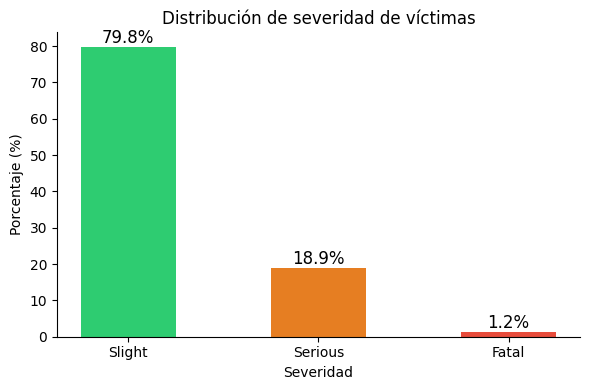

In [18]:
plot_target_dist(target_counts.index, target_counts.values * 100)

In [19]:
accidents[target_col] = accidents[target_col].replace({2:1,3:0})

In [20]:
target_counts = accidents[target_col].replace(casualty_value_map[target_col]).replace({0:'Slight'}).value_counts(normalize=True)
target_counts

casualty_severity
Slight    0.798118
Fatal     0.201882
Name: proportion, dtype: float64

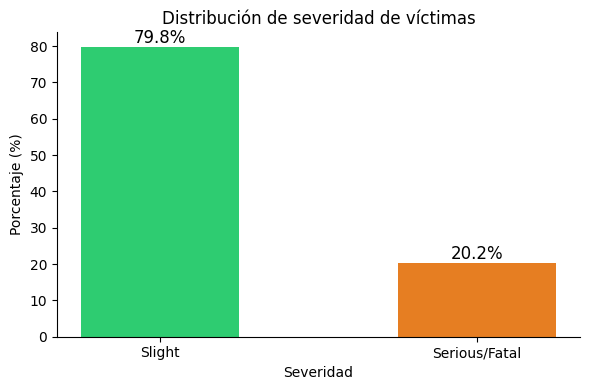

In [21]:
plot_target_dist(['Slight', 'Serious/Fatal'], target_counts.values * 100)

## Eliminación de columnas problemáticas

Identificamos y descartamos cuatro grupos de columnas no útiles para el modelo:

- **Históricas**: derivadas de agregaciones pasadas que podrían producir data leakage.
- **Relacionadas con el target**: columnas que contienen información directamente derivada de la severidad.
- **Referencia e índices**: identificadores sin valor predictivo.
- **Alta cardinalidad**: variables geográficas o de texto libre con demasiados valores únicos que dificultarían el entrenamiento.
- **Alto porcentaje de desconocidos (-1)**: columnas donde el valor -1 ("Unknown","Missing Data,Not classified")
  representa una proporción significativa, dejándolas prácticamente inservibles.

In [22]:
#Columnas de historicos
hist_cols = [col for col in accidents.columns if col.endswith('_historic')]
hist_cols

['vehicle_manoeuvre_historic',
 'vehicle_location_restricted_lane_historic',
 'journey_purpose_of_driver_historic',
 'junction_detail_historic',
 'pedestrian_crossing_human_control_historic',
 'pedestrian_crossing_physical_facilities_historic',
 'carriageway_hazards_historic']

In [23]:
[col for col in accidents.columns if 'severity' in col]

['casualty_severity',
 'enhanced_casualty_severity',
 'casualty_adjusted_severity_serious',
 'casualty_adjusted_severity_slight',
 'collision_severity',
 'enhanced_severity_collision',
 'collision_adjusted_severity_serious',
 'collision_adjusted_severity_slight']

In [24]:
#Columnas relacionadas con el target
target_related_cols = [
    'casualty_adjusted_severity_serious',
    'casualty_adjusted_severity_slight',
    'enhanced_casualty_severity',
    'enhanced_severity_collision',
    'collision_adjusted_severity_serious',
    'collision_adjusted_severity_slight',
    'collision_severity',
    'did_police_officer_attend_scene_of_accident'
]

In [25]:
#Columnas de indice y referencias
ref_cols = [
    'collision_year',
    'casualty_reference',
    'vehicle_reference',
]

In [26]:
cardinality = accidents.nunique().sort_values(ascending=False)
ratio = cardinality / len(cas_veh)
dtypes = accidents.dtypes

df_cardinality = pd.DataFrame({
    'unique_values': cardinality,
    'ratio': ratio,
    'dtype': dtypes
}).query('unique_values > 20').sort_values(by='ratio', ascending=False)
df_cardinality

,unique_values,ratio,dtype
collision_index,503395,0.785914,str
longitude,454003,0.708802,float64
latitude,432753,0.675626,float64
location_northing_osgr,259640,0.405357,float64
location_easting_osgr,242311,0.378302,float64
collision_adjusted_severity_serious,103068,0.160913,float64
collision_adjusted_severity_slight,103068,0.160913,float64
lsoa_of_driver,36335,0.056727,str
lsoa_of_casualty,36240,0.056579,str
lsoa_of_accident_location,35411,0.055285,str


In [27]:
df_cardinality.index

Index(['collision_index', 'longitude', 'latitude', 'location_northing_osgr',
       'location_easting_osgr', 'collision_adjusted_severity_serious',
       'collision_adjusted_severity_slight', 'lsoa_of_driver',
       'lsoa_of_casualty', 'lsoa_of_accident_location',
       'casualty_adjusted_severity_serious',
       'casualty_adjusted_severity_slight', 'first_road_number',
       'second_road_number', 'date', 'time', 'engine_capacity_cc',
       'generic_make_model', 'local_authority_district',
       'local_authority_ons_district', 'local_authority_highway',
       'local_authority_highway_current', 'age_of_casualty', 'age_of_driver',
       'age_of_vehicle', 'casualty_reference', 'police_force',
       'vehicle_reference', 'number_of_casualties', 'casualty_type',
       'vehicle_type'],
      dtype='str')

In [28]:
#Columnas de alta cardinalidad
high_card_cols = [
    'lsoa_of_driver',
    'lsoa_of_casualty',
    'lsoa_of_accident_location',
    'generic_make_model',
    'location_northing_osgr',
    'location_easting_osgr',
    'local_authority_district',
    'local_authority_ons_district',
    'local_authority_highway',
    'local_authority_highway_current',
    'first_road_number',
    'second_road_number',
    'casualty_reference'
]

In [29]:
(accidents == -1).mean().mul(100).loc[lambda x: x > 0].sort_values(ascending=False)

casualty_distance_banding                           82.668690
driver_distance_banding                             82.451489
local_authority_district                            82.106871
enhanced_severity_collision                         45.999416
junction_control                                    43.297591
enhanced_casualty_severity                          42.307146
second_road_number                                  39.189812
engine_capacity_cc                                  25.174144
age_of_vehicle                                      24.142944
propulsion_code                                     24.106561
vehicle_manoeuvre_historic                          13.036777
special_conditions_at_site                          13.021631
carriageway_hazards_historic                        13.019445
pedestrian_crossing_human_control_historic          12.919042
pedestrian_crossing_physical_facilities_historic    12.912952
vehicle_location_restricted_lane_historic           12.748373
journey_

In [30]:
high_unkw_cols = [
    'casualty_distance_banding',
    'driver_distance_banding',
    'junction_control',
    'age_of_vehicle',
    'engine_capacity_cc',
    'second_road_number',
    'propulsion_code',
]

In [31]:
accidents[accidents['speed_limit'] == -1].shape[0]

15

In [32]:
accidents = accidents[accidents['speed_limit'] != -1]

In [33]:
cols_to_drop = hist_cols + target_related_cols + ref_cols + high_card_cols + high_unkw_cols
accidents = accidents.drop(columns=cols_to_drop)

### Nuevas columnas

In [34]:
accidents['day_period'] = accidents['time'].apply(lambda x: get_day_period_from_time(x))

In [35]:
accidents["geo_hash"] = accidents.apply(
    lambda x: geohash2.encode(x['latitude'], x['longitude'], precision=4),axis=1
)

### Split de datos
Usamos `GroupShuffleSplit` respetando los grupos por `collision_index`, de modo que todas las víctimas de un mismo accidente queden en el mismo fold. De lo contrario estaríamos ante un **problema de filtración** de datos, ya que el modelo podría estar evaluando en el X_test el contexto de un accidente que ya ha visto anteriormente en los datos de X_train, inflando las métricas artificialmente.

In [36]:
X = accidents.drop(columns=[target_col,'collision_index'])
y = accidents[target_col].astype(int)

gss = GroupShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
groups = accidents['collision_index']
train_idx, test_idx = next(gss.split(X, y, groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]

In [37]:
print('Train data:', X_train.shape, y_train.shape)
print('Train groups: ', groups_train.shape)
print('Test data: ', X_test.shape, y_test.shape)

Train data: (512334, 55) (512334,)
Train groups:  (512334,)
Test data:  (128070, 55) (128070,)


In [38]:
accidents.to_parquet(Path(DATA_PROCESSED_DIR) / 'accidents.parquet')

X_train.to_parquet(Path(X_TRAIN_PATH))
X_test.to_parquet(Path(X_TEST_PATH))
y_train.to_frame().to_parquet(Path(Y_TRAIN_PATH))
y_test.to_frame().to_parquet(Path(Y_TEST_PATH))

groups_train.to_frame().to_parquet(Path(GROUPS_TRAIN_PATH))